In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
train = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
test = pd.read_csv('/kaggle/input/competitions/digit-recognizer/test.csv')

# Quick look
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nFirst few rows:")
print(train.head())

Train shape: (42000, 785)
Test shape: (28000, 784)

First few rows:
   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pix

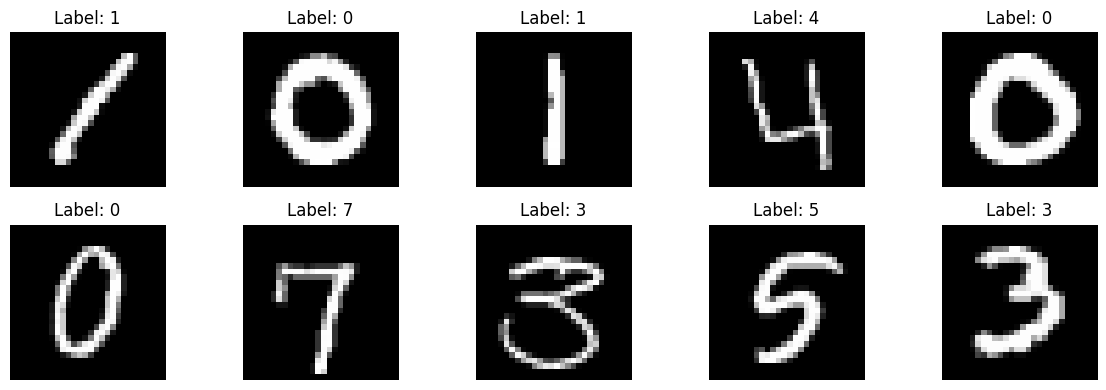

In [2]:
# Visualize first 10 images
plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i+1)
    
    # Get the pixel values (all columns except 'label')
    image = train.iloc[i, 1:].values  # Skip the label column
    
    # Reshape from 784 pixels to 28x28 grid
    image = image.reshape(28, 28)
    
    # Display the image
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {train.iloc[i, 0]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Step 1: Separate features (X) and labels (y)
X = train.drop('label', axis=1).values  # All pixels
y = train['label'].values                # The digit labels

print("X shape:", X.shape)  # Should be (42000, 784)
print("y shape:", y.shape)  # Should be (42000,)

# Step 2: Normalize pixels from 0-255 to 0-1
X = X / 255.0
print("\nAfter normalization:")
print("X min:", X.min(), "X max:", X.max())

# Step 3: One-hot encode labels
# Example: label 3 becomes [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y = to_categorical(y, num_classes=10)
print("\nAfter one-hot encoding:")
print("y shape:", y.shape)  # Should be (42000, 10)
print("Example - first label:", y[0])

# Step 4: Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nFinal splits:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

2026-03-26 11:35:53.443184: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774524953.691972      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774524953.764432      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774524954.336207      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774524954.336270      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774524954.336273      17 computation_placer.cc:177] computation placer alr

X shape: (42000, 784)
y shape: (42000,)

After normalization:
X min: 0.0 X max: 1.0

After one-hot encoding:
y shape: (42000, 10)
Example - first label: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]

Final splits:
X_train: (33600, 784)
y_train: (33600, 10)
X_val: (8400, 784)
y_val: (8400, 10)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Build the model
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),  # Hidden layer 1
    Dense(64, activation='relu'),                        # Hidden layer 2
    Dense(10, activation='softmax')                      # Output layer
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# View the architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-26 11:36:22.863653: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8432 - loss: 0.5315 - val_accuracy: 0.9485 - val_loss: 0.1717
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9608 - loss: 0.1299 - val_accuracy: 0.9618 - val_loss: 0.1305
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9728 - loss: 0.0872 - val_accuracy: 0.9639 - val_loss: 0.1232
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9821 - loss: 0.0594 - val_accuracy: 0.9685 - val_loss: 0.1054
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9850 - loss: 0.0462 - val_accuracy: 0.9699 - val_loss: 0.1048
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9889 - loss: 0.0370 - val_accuracy: 0.9701 - val_loss: 0.1051
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9918 - loss: 0.0256 - val_accuracy: 0.9735 - val_loss: 0.0957
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9925 - loss: 0.0231 - 

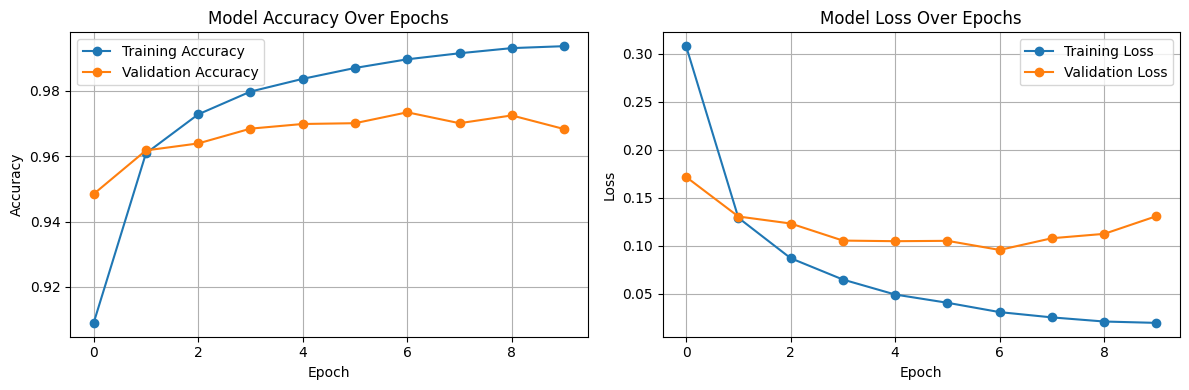

In [6]:
import matplotlib.pyplot as plt

# Plot training history
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


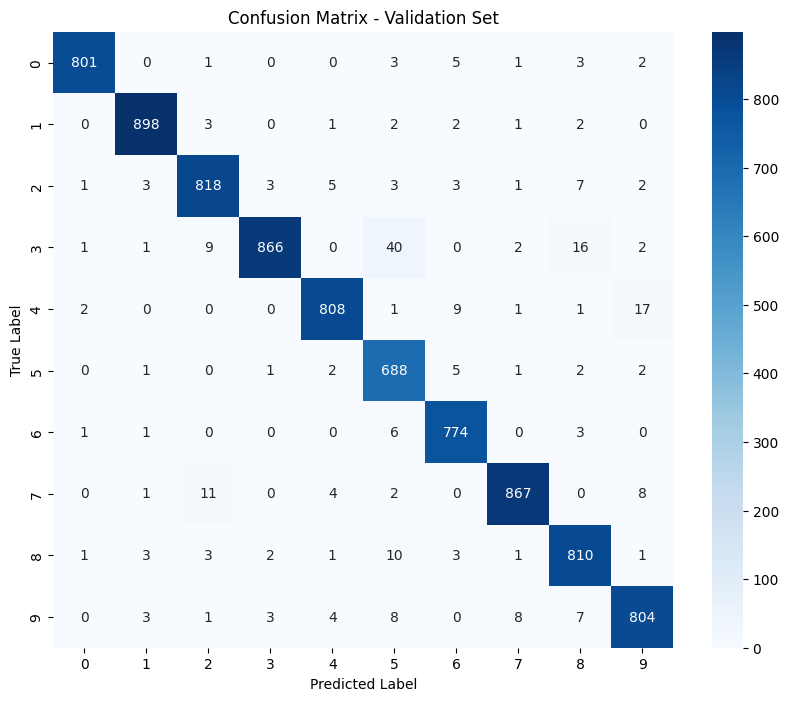


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       816
           1       0.99      0.99      0.99       909
           2       0.97      0.97      0.97       846
           3       0.99      0.92      0.96       937
           4       0.98      0.96      0.97       839
           5       0.90      0.98      0.94       702
           6       0.97      0.99      0.98       785
           7       0.98      0.97      0.98       893
           8       0.95      0.97      0.96       835
           9       0.96      0.96      0.96       838

    accuracy                           0.97      8400
   macro avg       0.97      0.97      0.97      8400
weighted avg       0.97      0.97      0.97      8400



In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Make predictions on validation set
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels
y_true_classes = np.argmax(y_val, axis=1)   # Convert one-hot back to class labels

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - Validation Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Detailed metrics
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, 
                          target_names=[str(i) for i in range(10)]))

In [8]:
# Prepare test data (same normalization as training)
X_test = test.values / 255.0

# Make predictions
test_predictions = model.predict(X_test)
test_pred_classes = np.argmax(test_predictions, axis=1)

# Create submission file
submission = pd.DataFrame({
    'ImageId': range(1, len(test_pred_classes) + 1),
    'Label': test_pred_classes
})

# Save to CSV
submission.to_csv('submission.csv', index=False)

print("Submission file created!")
print("\nFirst 10 predictions:")
print(submission.head(10))

# Check distribution
print("\nPredicted digit distribution:")
print(submission['Label'].value_counts().sort_index())

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Submission file created!

First 10 predictions:
   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      0
4        5      3
5        6      7
6        7      0
7        8      3
8        9      0
9       10      3

Predicted digit distribution:
Label
0    2754
1    3211
2    2844
3    2598
4    2722
5    2751
6    2787
7    2867
8    2757
9    2709
Name: count, dtype: int64


In [9]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv
